# Student performance: early warning and support priorities
STDS 36103, Assessment Task 2 (group project). Code appendix.

**Data:** Portuguese-course file of the Student Performance Data Set (`student-por.csv`, 649 students, 33 variables).
Cortez and Silva (2008); UCI Machine Learning Repository; Kaggle copy (CC0 licence).

**Research questions**
1. **RQ1.** Can a student's first-term grade (G1) show early in the year whether the student is likely to fail the final grade (G3 below 10)? Method: logistic regression.
2. **RQ2.** Which study and lifestyle habits (weekly study time, school-day alcohol use, going out with friends) are linked to higher or lower final grades? Method: multiple linear regression.
3. **RQ3.** Which groups of students have lower final grades (past class failures, school MS, no plans for higher education)? Method: the same multiple linear regression, plus fail rates by group.



## 0. Setup

In [77]:
import os, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import roc_auc_score, roc_curve

# warnings.filterwarnings("ignore")
# os.makedirs("figures", exist_ok=True)
# RNG = 42
# KEY = {}   # numbers used in the report

# sns.set_theme(style="whitegrid", font="DejaVu Sans")
# plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "axes.titleweight": "bold", "axes.titlesize": 12,
#                      "axes.labelsize": 11, "axes.spines.top": False, "axes.spines.right": False})
def save(fig, name):
    fig.tight_layout()
    #fig.savefig(f"figures/{name}.png", bbox_inches="tight")
    plt.show()

## 1. Data checks

In [78]:
df = pd.read_csv("student-por.csv")
df["fail"] = (df.G3 < 10).astype(int)          # pass mark is 10 out of 20
print("Shape:", df.shape, "| missing:", int(df.isna().sum().sum()), "| duplicates:", int(df.duplicated().sum()))
print("Sex:", df.sex.value_counts().to_dict(), "| age range:", df.age.min(), "to", df.age.max())
print("Failed (G3 < 10):", int(df.fail.sum()), f"({df.fail.mean():.1%})")
print("Mean G3:", round(df.G3.mean(), 2), "| median:", df.G3.median())


Shape: (649, 34) | missing: 0 | duplicates: 0
Sex: {'F': 383, 'M': 266} | age range: 15 to 22
Failed (G3 < 10): 100 (15.4%)
Mean G3: 11.91 | median: 12.0


Fifteen students have `G3 = 0`. All fifteen have zero absences and a non-zero term-1 grade, which points to students who did not sit the final exam.
We keep them in the analysis and count them as fails, because a school would want to flag them. Section 5 checks how much they affect the regression.

G3 = 0: 15 | absences = 0: 15 | G2 = 0: 7 | at school MS: 14


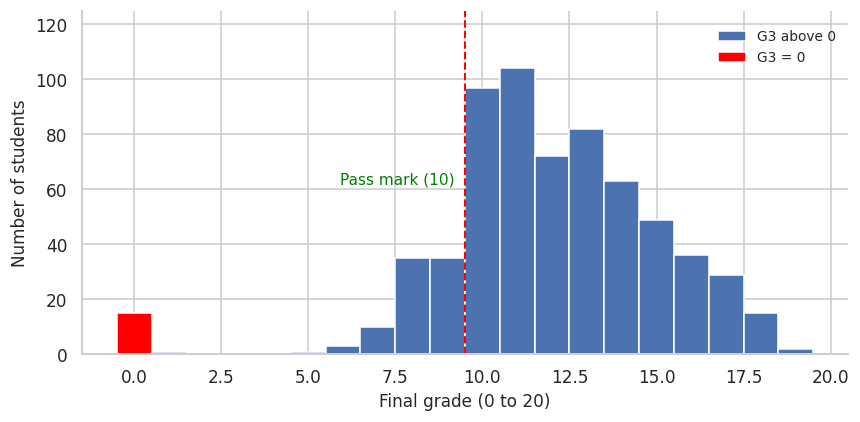

In [79]:
zero = df[df.G3 == 0]
print("G3 = 0:", len(zero), "| absences = 0:", int((zero.absences == 0).sum()), "| G2 = 0:", int((zero.G2 == 0).sum()),
      "| at school MS:", int((zero.school == "MS").sum()))

fig, ax = plt.subplots(figsize=(8, 4))
bins = np.arange(-0.5, 20.5, 1)
ax.hist(df.G3[df.G3 > 0], bins=bins, edgecolor="white", label="G3 above 0")
ax.hist(df.G3[df.G3 == 0], bins=bins, color="red", edgecolor="white", label="G3 = 0")
ax.axvline(9.5, color="red", ls="--", lw=1.3)
ax.text(9.2, 62, "Pass mark (10)", ha="right", color="green", fontsize=10)
ax.set(xlabel="Final grade (0 to 20)", ylabel="Number of students")
ax.legend(frameon=False, loc="upper right", bbox_to_anchor=(1.0, 0.98), fontsize=9) 
ax.set_ylim(0, 125)
save(fig, "fig1_g3_distribution")

## 2. RQ1: does the term-1 grade (G1) warn us early? (logistic regression)

Outcome: `fail = 1` if G3 is below 10. Predictor: G1. We first compare fail rates for students below and at or above the pass mark in term 1,
then fit a logistic regression and read the coefficient as an odds ratio.

In [80]:
df["g1_low"] = (df.G1 < 10).astype(int)
ct = pd.crosstab(df.g1_low, df.fail)
print(ct)
tab = pd.DataFrame({"students": ct.sum(axis=1), "failed": ct[1], "fail_rate": (ct[1] / ct.sum(axis=1)).round(3)})
print(tab)
sens = ct.loc[1, 1] / ct[1].sum()
spec = ct.loc[0, 0] / ct[0].sum()
ppv = ct.loc[1, 1] / ct.loc[1].sum()
print(f"Share of fails with G1 < 10 (sensitivity): {sens:.1%} | specificity: {spec:.1%} | fail rate if G1 < 10: {ppv:.1%} | flagged: {ct.loc[1].sum()}")
r_g1 = stats.pearsonr(df.G1, df.G3)[0]
r_g2 = stats.pearsonr(df.G2, df.G3)[0]
print("Correlation with G3: G1 =", round(r_g1, 2), "| G2 =", round(r_g2, 2))


fail      0   1
g1_low         
0       480  12
1        69  88
        students  failed  fail_rate
g1_low                             
0            492      12      0.024
1            157      88      0.561
Share of fails with G1 < 10 (sensitivity): 88.0% | specificity: 87.4% | fail rate if G1 < 10: 56.1% | flagged: 157
Correlation with G3: G1 = 0.83 | G2 = 0.92


In [81]:
m_rq1 = smf.logit("fail ~ G1", data=df).fit(disp=0)
print(m_rq1.summary().tables[1])
orr = np.exp(m_rq1.params["G1"])
ci = np.exp(m_rq1.conf_int().loc["G1"])
print(f"Odds ratio per G1 point = {orr:.2f} (95% CI {ci[0]:.2f} to {ci[1]:.2f}), p = {m_rq1.pvalues['G1']:.2g}, McFadden R2 = {m_rq1.prsquared:.2f}")
auc_in = roc_auc_score(df.fail, m_rq1.predict(df))
oof = np.zeros(len(df))
for tr, te in StratifiedKFold(10, shuffle=True, random_state=RNG).split(df, df.fail):
    oof[te] = smf.logit("fail ~ G1", data=df.iloc[tr]).fit(disp=0).predict(df.iloc[te])
auc_cv = roc_auc_score(df.fail, oof)
print(f"AUC in sample = {auc_in:.3f}, 10-fold cross-validated = {auc_cv:.3f}")
probs = {g: float(m_rq1.predict(pd.DataFrame({'G1': [g]}))[0]) for g in (8, 9, 10, 11)}
print({k: round(v, 3) for k, v in probs.items()})

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     10.0119      1.077      9.294      0.000       7.900      12.123
G1            -1.2153      0.120    -10.165      0.000      -1.450      -0.981
Odds ratio per G1 point = 0.30 (95% CI 0.23 to 0.37), p = 2.8e-24, McFadden R2 = 0.51
AUC in sample = 0.947, 10-fold cross-validated = 0.941
{8: 0.572, 9: 0.284, 10: 0.105, 11: 0.034}


### Checks for the logistic model
With one predictor, the main assumption is that the log-odds of failing change linearly with G1. We test this by adding a squared term (likelihood-ratio test)
and by comparing observed and fitted fail rates at each G1 level.

Squared term: LR = 21.2, p = 4.1e-06
      n  observed  fitted
G1c                      
5     8     0.875   0.981
6     9     0.889   0.938
7    33     0.818   0.818
8    42     0.667   0.572
9    65     0.277   0.284
10   95     0.105   0.105
11   91     0.022   0.034
12   82     0.000   0.010
13   72     0.000   0.003
14   71     0.000   0.001
15   35     0.000   0.000
16   46     0.000   0.000


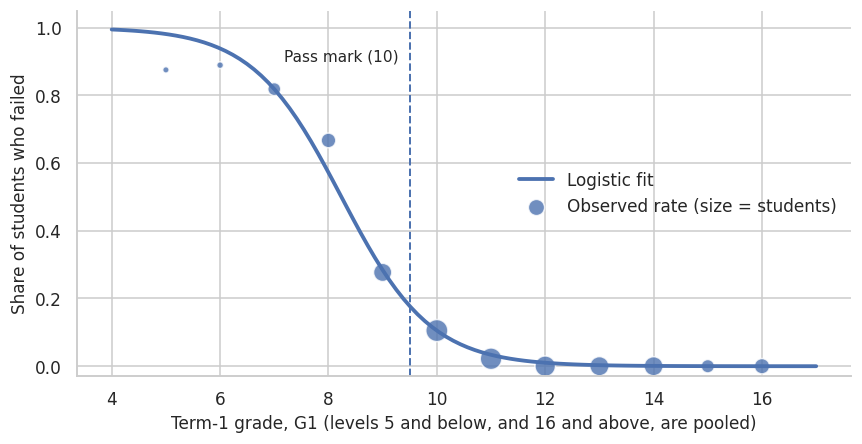

In [82]:
m_quad = smf.logit("fail ~ G1 + I(G1**2)", data=df).fit(disp=0)
lr = 2 * (m_quad.llf - m_rq1.llf)
p_lr = stats.chi2.sf(lr, 1)
print(f"Squared term: LR = {lr:.1f}, p = {p_lr:.2g}")
lv = df.assign(G1c=df.G1.clip(5, 16)).groupby("G1c").agg(n=("fail", "size"), observed=("fail", "mean"))
lv["fitted"] = m_rq1.predict(pd.DataFrame({"G1": lv.index})).values
print(lv.round(3))

fig, ax = plt.subplots(figsize=(8, 4.2))
xs = np.linspace(4, 17, 100)
ax.plot(xs, m_rq1.predict(pd.DataFrame({"G1": xs})), lw=2.5, label="Logistic fit")
ax.scatter(lv.index, lv.observed, s=lv.n * 2.2, alpha=.8, edgecolor="white", label="Observed rate (size = students)")
ax.axvline(9.5, ls="--", lw=1.3)
ax.text(9.3, 0.9, "Pass mark (10)", ha="right", fontsize=10)

ax.set(xlabel="Term-1 grade, G1 (levels 5 and below, and 16 and above, are pooled)", ylabel="Share of students who failed",
       ylim=(-0.03, 1.05))
ax.legend(frameon=False, loc="center right")
save(fig, "fig2_rq1_logistic")

## 3. Variable selection for RQ2 and RQ3

G1 and G2 are earlier grades in the same subject and correlate strongly with G3, so they stay out of this model. The candidates are the other survey variables:
categorical variables are dummy coded (39 columns). Figure 3 shows that students who go out very rarely or very often fail more often than the middle groups,
so we add one yes/no variable, `goext` (going out = 1 or 5). Backward elimination and forward selection both use a 0.01 threshold, because 40 candidates raise the chance of a false positive.

Dummy-coded candidate variables: 39
Candidates including goext: 40


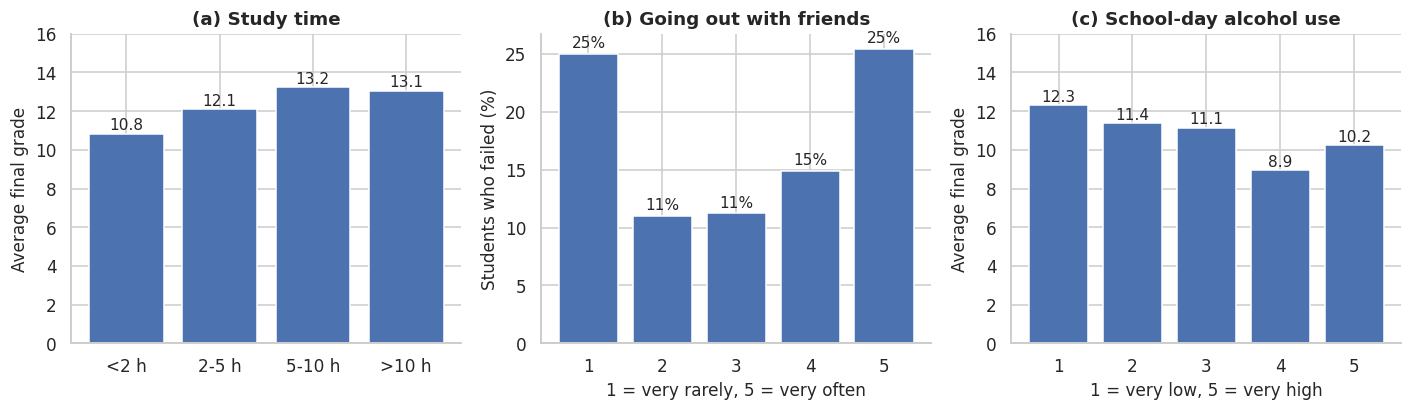

In [ ]:
X = df.drop(columns=["G1", "G2", "G3", "fail", "g1_low"])
Xd = pd.get_dummies(X, columns=list(X.select_dtypes(exclude="number").columns), drop_first=True).astype(float)
print("Dummy-coded candidate variables:", Xd.shape[1])
Xd["goext"] = df.goout.isin([1, 5]).astype(float)
y = df.G3
print("Candidates including goext:", Xd.shape[1])

fig, ax = plt.subplots(1, 3, figsize=(13, 3.9))
st = df.groupby("studytime").G3.mean()
ax[0].bar(["<2 h", "2-5 h", "5-10 h", ">10 h"], st.values)
ax[0].set(title="(a) Study time", ylabel="Average final grade", ylim=(0, 16))
for i, v in enumerate(st.values): 
    ax[0].text(i, v + .2, f"{v:.1f}", ha="center", fontsize=10)
go = df.groupby("goout").fail.mean() * 100
ax[1].bar(go.index.astype(str), go.values)
ax[1].set(title="(b) Going out with friends", xlabel="1 = very rarely, 5 = very often", ylabel="Students who failed (%)")
for i, v in enumerate(go.values): 
    ax[1].text(i, v + .5, f"{v:.0f}%", ha="center", fontsize=10)
al = df.groupby("Dalc").G3.mean()
ax[2].bar(al.index.astype(str), al.values)
ax[2].set(title="(c) School-day alcohol use", xlabel="1 = very low, 5 = very high", ylabel="Average final grade", ylim=(0, 16))
for i, v in enumerate(al.values): 
    ax[2].text(i, v + .2, f"{v:.1f}", ha="center", fontsize=10)
save(fig, "fig3_habits")

In [ ]:
def backward(Xm, ym, thr):
    cols = list(Xm.columns)
    while True:
        m = sm.OLS(ym, sm.add_constant(Xm[cols])).fit()
        p = m.pvalues.drop("const")
        worst = p.idxmax()
        if p[worst] > thr: 
            cols.remove(worst)
        else: 
            return cols
def forward(Xm, ym, thr):
    cols, rest = [], list(Xm.columns)
    while rest:
        ps = {c: sm.OLS(ym, sm.add_constant(Xm[cols + [c]])).fit().pvalues[c] for c in rest}
        best = min(ps, key=ps.get)
        if ps[best] < thr: 
            cols.append(best)
            rest.remove(best)
        else: 
            break
    return cols
ALPHA = 0.01
bwd = backward(Xd, y, ALPHA)
fwd = forward(Xd, y, ALPHA)
print("Backward elimination keeps", len(bwd), ":", sorted(bwd))
print("Forward selection keeps  ", len(fwd), ":", sorted(fwd))
print("Shared:", len(set(bwd) & set(fwd)), "| only backward:", sorted(set(bwd) - set(fwd)), "| only forward:", sorted(set(fwd) - set(bwd)))


Backward elimination keeps 9 : ['Dalc', 'Fedu', 'failures', 'goext', 'health', 'higher_yes', 'school_MS', 'schoolsup_yes', 'studytime']
Forward selection keeps   9 : ['Dalc', 'Medu', 'failures', 'goext', 'health', 'higher_yes', 'school_MS', 'schoolsup_yes', 'studytime']
Shared: 8 | only backward: ['Fedu'] | only forward: ['Medu']


## 4. Final linear model (RQ2 and RQ3)
Outcome G3 (0 to 20), n = 649. Predictors are the nine variables kept by backward elimination.
RQ2 reads the habit variables (`studytime`, `Dalc`, `goext`). RQ3 reads the group variables (`failures`, `school_MS`, `higher_yes`, `schoolsup_yes`). `Fedu` and `health` are controls.

In [85]:
ols = sm.OLS(y, sm.add_constant(Xd[bwd])).fit()
rob = sm.OLS(y, sm.add_constant(Xd[bwd])).fit(cov_type="HC3")
label = {"higher_yes": "Plans higher education (yes)", "studytime": "Weekly study time (per level)", "Dalc": "School-day alcohol (per level)",
         "goext": "Goes out very rarely or very often (yes)", "failures": "Past class failures (per failure)", "school_MS": "School MS (vs GP)",
         "schoolsup_yes": "Extra school support (yes)", "Fedu": "Father's education (per level)", "health": "Self-rated health (per level)"}
role = {"studytime": "RQ2 habit", "Dalc": "RQ2 habit", "goext": "RQ2 habit", "failures": "RQ3 group", "school_MS": "RQ3 group",
        "higher_yes": "RQ3 group", "schoolsup_yes": "RQ3 group", "Fedu": "control", "health": "control"}
coef = pd.DataFrame({"coef": rob.params, "ci_low": rob.conf_int()[0], "ci_high": rob.conf_int()[1], "p_HC3": rob.pvalues}).drop("const")
coef["role"] = coef.index.map(role)
coef.index = coef.index.map(label.get)
print(f"n = {int(ols.nobs)}, R2 = {ols.rsquared:.3f}, adjusted R2 = {ols.rsquared_adj:.3f}, intercept = {ols.params['const']:.2f}")
print(coef.round(3))

n = 649, R2 = 0.327, adjusted R2 = 0.317, intercept = 11.17
                                           coef  ci_low  ci_high  p_HC3  \
Father's education (per level)            0.280   0.082    0.479  0.006   
Weekly study time (per level)             0.503   0.259    0.748  0.000   
Past class failures (per failure)        -1.426  -1.831   -1.020  0.000   
School-day alcohol (per level)           -0.397  -0.676   -0.118  0.005   
Self-rated health (per level)            -0.198  -0.338   -0.058  0.006   
School MS (vs GP)                        -1.360  -1.878   -0.843  0.000   
Extra school support (yes)               -1.288  -1.965   -0.611  0.000   
Plans higher education (yes)              1.713   0.997    2.428  0.000   
Goes out very rarely or very often (yes) -0.778  -1.312   -0.243  0.004   

                                               role  
Father's education (per level)              control  
Weekly study time (per level)             RQ2 habit  
Past class failures (per fa

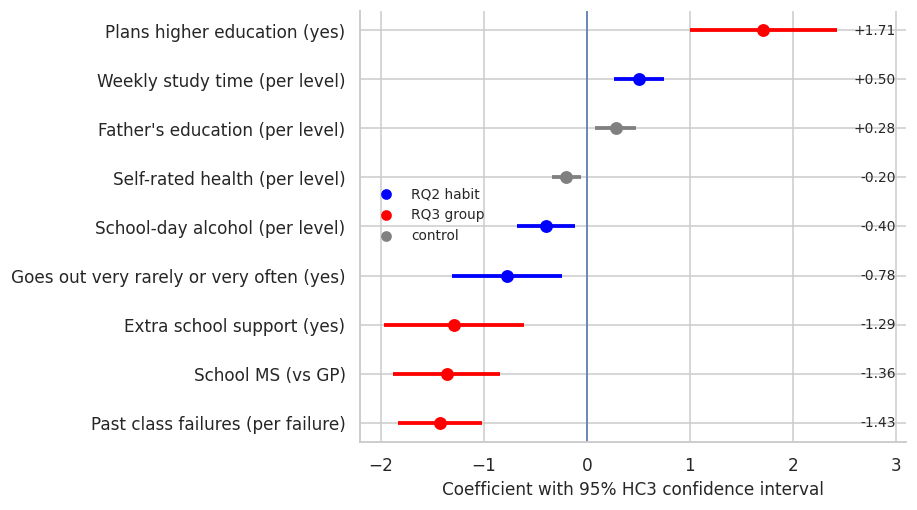

In [86]:
cp = coef.sort_values("coef")
colmap = {"RQ2 habit": "blue", "RQ3 group": "red", "control": "grey"}
fig, ax = plt.subplots(figsize=(8.5, 4.8))
for i, (name, r) in enumerate(cp.iterrows()):
    ax.hlines(i, r.ci_low, r.ci_high, color=colmap[r.role], lw=2.5)
    ax.scatter(r.coef, i, color=colmap[r.role], s=55, zorder=3)
    ax.text(3.0, i, f"{r.coef:+.2f}", va="center", ha="right", fontsize=9)
ax.set_yticks(range(len(cp)))
ax.set_yticklabels(cp.index)
ax.axvline(0, lw=1)
ax.set_xlim(-2.2, 3.1)
for k, v in colmap.items(): 
    ax.scatter([], [], color=v, label=k)
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.0, 0.62), fontsize=9)
ax.set(xlabel="Coefficient with 95% HC3 confidence interval")

save(fig, "fig4_coefficients")

### 4.1 Fail rates by group (RQ3)

                    group reference  fail_%    n   comparison  fail_%_comp  \
0           Past failures      None     9.3  549  One or more         49.0   
1  Plans higher education        No    47.8   69          Yes         11.6   
2                  School        GP     7.6  423           MS         30.1   

   n_comp  
0     100  
1     580  
2     226  


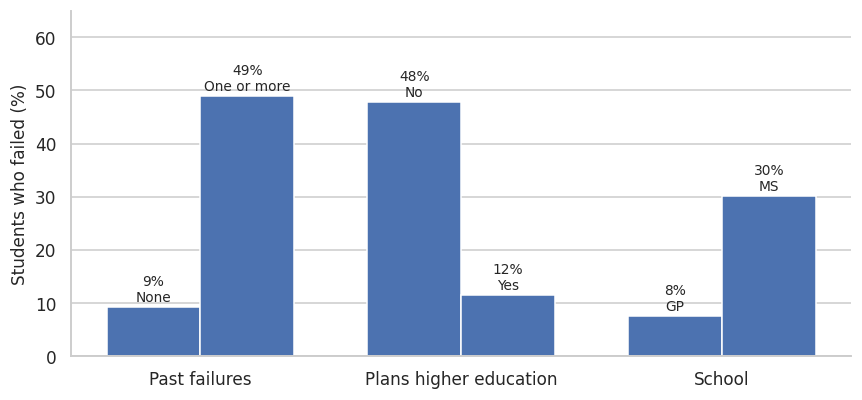

In [ ]:
groups = {
    "Past failures": {
        "column": "failures",
        "is_comparison": lambda s: s > 0,
        "ref_label": "None",
        "comp_label": "One or more",
    },
    "Plans higher education": {
        "column": "higher",
        "is_comparison": lambda s: s == "yes",
        "ref_label": "No",
        "comp_label": "Yes",
    },
    "School": {
        "column": "school",
        "is_comparison": lambda s: s == "MS",
        "ref_label": "GP",
        "comp_label": "MS",
    },
}

rows = []
for name, g in groups.items():
    is_comp = g["is_comparison"](df[g["column"]])
    ref_students = df[~is_comp]
    comp_students = df[is_comp]

    rows.append({
        "group": name,
        "reference": g["ref_label"],
        "fail_%": round(ref_students["fail"].mean() * 100, 1),
        "n": len(ref_students),
        "comparison": g["comp_label"],
        "fail_%_comp": round(comp_students["fail"].mean() * 100, 1),
        "n_comp": len(comp_students),
    })

gt = pd.DataFrame(rows)
print(gt)

KEY["group_rates"] = {
    r["group"]: [float(r["fail_%"]), int(r["n"]), float(r["fail_%_comp"]), int(r["n_comp"])]
    for _, r in gt.iterrows()
}

BAR_COLOR = "C0"   
bar_width = 0.36

fig, ax = plt.subplots(figsize=(8, 3.8))
for i, r in gt.iterrows():
    left_x, right_x = i - bar_width / 2, i + bar_width / 2

    ax.bar(left_x, r["fail_%"], bar_width, color=BAR_COLOR)
    ax.bar(right_x, r["fail_%_comp"], bar_width, color=BAR_COLOR)

    # Label above each bar: percentage on the first line, category name on the second
    ax.text(left_x, r["fail_%"] + 1, f"{r['fail_%']:.0f}%\n{r['reference']}",
            ha="center", fontsize=9)
    ax.text(right_x, r["fail_%_comp"] + 1, f"{r['fail_%_comp']:.0f}%\n{r['comparison']}",
            ha="center", fontsize=9)

ax.grid(axis="x", visible=False)
ax.set_xticks(range(len(gt)))
ax.set_xticklabels(gt["group"])
# ax.set(ylim=(0, 65), ylabel="Students who failed (%)", title="Figure 5. Fail rate by student group (RQ3)")
ax.set(ylim=(0, 65), ylabel="Students who failed (%)")
save(fig, "fig5_groups")

## 5. Assumption checks and mitigation
Checks: collinearity (VIF), influence (Cook's distance), equal variance (Breusch-Pagan) and normality of residuals (Shapiro-Wilk, Q-Q plot).
Mitigation: HC3 robust standard errors (used above) and a refit without the 15 students with G3 = 0.

Max VIF = 1.19 | max Cook's D = 0.044 | Cook's D > 4/n: 37
Breusch-Pagan p = 2e-05 | Shapiro-Wilk p = 5.7e-13 | residual skew = -0.71
Residual skew without G3 = 0: 0.22 | BP p without G3 = 0: 0.27
                                          all students  without G3 = 0  \
Father's education (per level)                   0.280           0.231   
Weekly study time (per level)                    0.503           0.452   
Past class failures (per failure)               -1.426          -1.227   
School-day alcohol (per level)                  -0.397          -0.353   
Self-rated health (per level)                   -0.198          -0.158   
School MS (vs GP)                               -1.360          -0.838   
Extra school support (yes)                      -1.288          -1.244   
Plans higher education (yes)                     1.713           1.688   
Goes out very rarely or very often (yes)        -0.778          -0.446   

                                          p (without G3 = 0)  

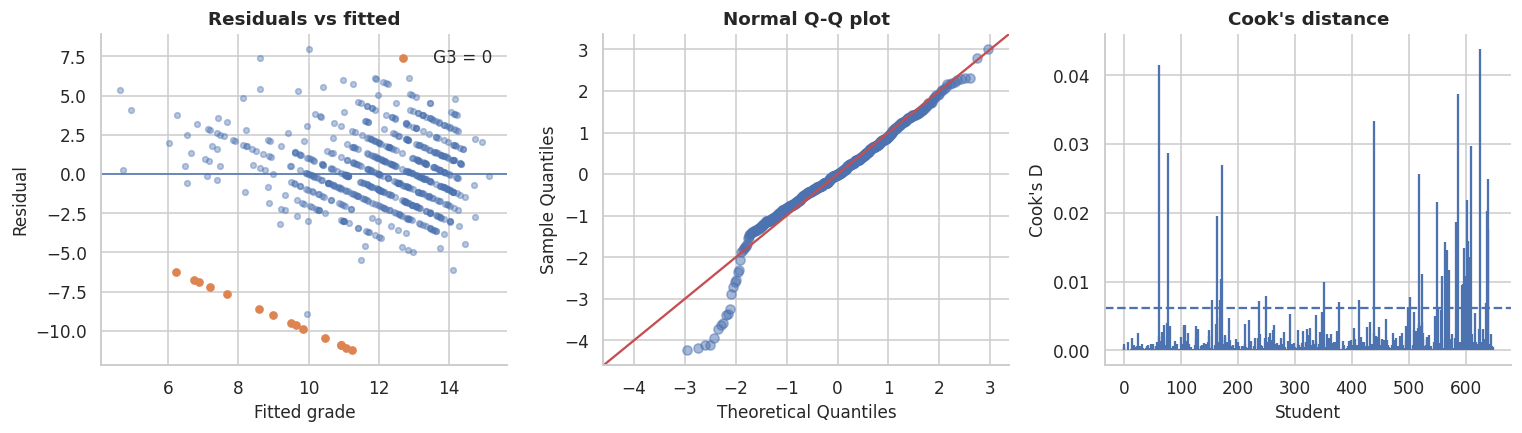

In [91]:
res, fit = ols.resid, ols.fittedvalues
Xc = sm.add_constant(Xd[bwd]).values
vif = pd.Series([variance_inflation_factor(Xc, i) for i in range(1, Xc.shape[1])], index=bwd)
cooks = ols.get_influence().cooks_distance[0]
bp = het_breuschpagan(res, ols.model.exog)
sw = stats.shapiro(res)
print(f"Max VIF = {vif.max():.2f} | max Cook's D = {cooks.max():.3f} | Cook's D > 4/n: {(cooks > 4/len(df)).sum()}")
print(f"Breusch-Pagan p = {bp[1]:.2g} | Shapiro-Wilk p = {sw.pvalue:.2g} | residual skew = {stats.skew(res):.2f}")
print("Residual skew without G3 = 0:", round(stats.skew(res[df.G3 > 0]), 2), "| BP p without G3 = 0:", f"{het_breuschpagan(res[df.G3 > 0], ols.model.exog[df.G3 > 0])[1]:.2g}")
nz = df.G3 > 0
ols_nz = sm.OLS(y[nz], sm.add_constant(Xd.loc[nz, bwd])).fit(cov_type="HC3")
cmp = pd.DataFrame({"all students": ols.params, "without G3 = 0": ols_nz.params, "p (without G3 = 0)": ols_nz.pvalues}).drop("const")
cmp.index = cmp.index.map(label.get)
print(cmp.round(3))
print("R2 without zeros:", round(ols_nz.rsquared, 3))
fig, ax = plt.subplots(1, 3, figsize=(14, 4.1))
z = df.G3 == 0
ax[0].scatter(fit[~z], res[~z], s=14, alpha=.4)
ax[0].scatter(fit[z], res[z], s=22, label="G3 = 0")
ax[0].axhline(0, lw=1)
ax[0].set(title="Residuals vs fitted", xlabel="Fitted grade", ylabel="Residual")
ax[0].legend(frameon=False)
sm.qqplot(res, line="45", fit=True, ax=ax[1], alpha=.5)
ax[1].set_title("Normal Q-Q plot")
ax[2].stem(np.arange(len(cooks)), cooks, markerfmt=" ", basefmt=" ")
ax[2].axhline(4 / len(df), ls="--")
ax[2].set(title="Cook's distance", xlabel="Student", ylabel="Cook's D")
save(fig, "figA1_diagnostics")

### 5.1 Out-of-sample check
Stepwise selection can over-fit. We repeat the whole selection inside each training fold (10-fold cross-validation) and compare it with a model that uses all 40 candidates.

In [89]:
r2f = lambda yt, p: 1 - ((yt - p) ** 2).sum() / ((yt - yt.mean()) ** 2).sum()
p_sel = np.zeros(len(df))
p_all = np.zeros(len(df))
p_fix = np.zeros(len(df))
for tr, te in KFold(10, shuffle=True, random_state=RNG).split(Xd):
    cols = backward(Xd.iloc[tr], y.iloc[tr], ALPHA)
    p_sel[te] = LinearRegression().fit(Xd.iloc[tr][cols], y.iloc[tr]).predict(Xd.iloc[te][cols])
    p_all[te] = LinearRegression().fit(Xd.iloc[tr], y.iloc[tr]).predict(Xd.iloc[te])
    p_fix[te] = LinearRegression().fit(Xd.iloc[tr][bwd], y.iloc[tr]).predict(Xd.iloc[te][bwd])
cv = {"selection repeated in each fold": p_sel, "all 40 candidates": p_all, "9 chosen variables (selection outside CV)": p_fix}
for k, p in cv.items(): print(f"{k}: CV R2 = {r2f(y, p):.3f}, RMSE = {np.sqrt(((y - p) ** 2).mean()):.2f}")

selection repeated in each fold: CV R2 = 0.264, RMSE = 2.77
all 40 candidates: CV R2 = 0.277, RMSE = 2.75
9 chosen variables (selection outside CV): CV R2 = 0.304, RMSE = 2.69


## 6. Numbers for the report

In [90]:
with open("key_numbers.json", "w") as f: json.dump(KEY, f, indent=1, default=float)
pd.Series({k: v for k, v in KEY.items() if not isinstance(v, (dict, list))})

n                        649
n_fail                   100
fail_rate              0.154
mean_g3                11.91
n_female                 383
n_male                   266
n_zero                    15
zero_ms                   14
g1_low_n                 157
g1_low_fail_rate       0.561
g1_ok_fail_rate        0.024
g1_ok_fail_n              12
g1_ok_n                  492
g1_low_fail_n             88
sens                    0.88
spec                   0.874
r_g1                    0.83
r_g2                    0.92
or_g1                    0.3
or_lo                   0.23
or_hi                   0.37
auc_in                 0.947
auc_cv                 0.941
mcfadden                0.51
p8                     0.572
p9                     0.284
p10                    0.105
p11                    0.034
quad_p              0.000004
n_g1_12                  306
n_fail_g1_12               0
go_mid                 0.122
go_ext                 0.253
st1                     10.8
st3           

## References
* Cortez, P. (2008). *Student Performance* [Data set]. UCI Machine Learning Repository. https://doi.org/10.24432/C5TG7T
* Cortez, P., & Silva, A. M. G. (2008). Using data mining to predict secondary school student performance. *Proceedings of the 5th FUture BUsiness TEChnology Conference*, 5-12.
* Seabold, S., & Perktold, J. (2010). statsmodels: Econometric and statistical modeling with Python. *Proceedings of the 9th Python in Science Conference*, 92-96.
* Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.